# Room Acoustic Parameter Calculation Using Pyrato

**[Pyrato](https://pyrato.readthedocs.io)** (**Py**thon **R**oom **A**coustics **T**ools) is a collection of functions for commonly used operations in room acoustics. It is part of the [pyfar](https://pyfar.org) ecosystem of Python packages for acoustics research.

We develop all packages openly across diverse research institutions, avoiding general branding of code or functionality. Contributions (in any form, i.e. reporting issues, submitting bug-fixes or implementation of new features) are welcome.
To get in touch, either contact us via

- [GitHub](https://github.com/pyfar).
- [Join the Slack channel](https://join.slack.com/t/pyfar/shared_invite/zt-2eacdhww2-iUiPnh_wuqg2zD939wL4kw).
- Write an old-school e-mail to info@pyfar.org.

## Example Gallery

This notebook, among others, is part of [pyfar's example gallery](https://pyfar-gallery.readthedocs.io/en/latest/).
The gallery contains:

- Notebooks supplementary to the [documentation](https://pyfar.readthedocs.io/en/stable).
- Application examples giving an overview over the use cases pyfar and its sub-packages.

All examples can either be 

- viewed as statically rendered web-pages,
- interactively executed on mybinder.org,
- downloaded and run locally.

The respective links are located at the top of each example notebook. 

To follow along with the workshop document, either navigate to [pyfar.org](https://pyfar.org) and scroll down to the **Workshops** section and select the **pyrato introduction**, or scan the following QR code:


In [4]:
# import packages
import pyfar as pf
import pyrato as pr
import numpy as np
import matplotlib.pyplot as plt

# set matplotlib backend for plotting
%matplotlib widget

# Room Acoustic Parameter Calculation Using Pyrato

This notebook introduces **Pyrato**, a room‑acoustics toolbox built on top of pyfar, and demonstrates how to calculate standard room acoustic parameters from a measured room impulse response. After a short introductory example with a synthetic shoebox RIR, the actual analysis uses a real RIR recorded in the Berliner Philharmonie, preserving the full decay to capture the authentic acoustics of the hall. The measured RIR is pre‑processed by bandpass filtering into octave bands and visualized (including interactive plots) to inspect the time‑domain structure in each band. On this basis, the notebook computes key parameters such as the Energy Decay Curve (EDC), reverberation time T20, clarity C80, and Speech Transmission Index (STI), illustrating a complete workflow from real‑world RIR measurement to parameter evaluation within the pyrato ecosystem.

The notebook covers:

- [Room Impulse Response](#room-impulse-response) — using `pyfar.signals.room_impulse_response`
- [Pre-Processing](#Pre-Processing) — bandpass filtering into octave bands
- [Interactive Plots](#interactive-plots) — visualizing band-passed RIRs
- [Room Acoustic Parameters](#room-acoustic-parameters)
  - [Energy Decay Curve (EDC)](#energy-decay-curve)
  - [Reverberation Time T20](#reverberation-time-t20)
  - [Clarity C80](#clarity-c80)
  - [Speech Transmission Index (STI)](#speech-transmission-index)

## Room Impulse Response

A room impulse response (RIR) characterizes a room's acoustics by capturing how sound travels from a source to a receiver, encoding reflections, reverberation, and room geometry.

We start with an analytically simulated RIR for a rectangular (shoebox) room with rigid walls using `pyrato.analytic.rectangular_room_rigid_walls [pyrato.analytic.rectangular_room_rigid_walls](https://pyrato.readthedocs.io/en/stable/modules/analytic.html#pyrato.analytic.rectangular_room_rigid_walls) from the [pyrato.analytic](https://pyrato.readthedocs.io/en/stable/modules/analytic.html) module. This allows full control over room geometry, source/receiver positions, and reverberation time.

The RIR is the foundation for all room acoustic parameter calculations. It contains information about the acoustic properties and geometry of the room.

In [5]:
# Room parameters
room_dimensions  = [8.0, 5.0, 3.0]   # [Lx, Ly, Lz] in meters
src_pos          = [1.0, 1.0, 1.5]   # source position [x, y, z]
rec_pos          = [5.0, 3.0, 1.5]   # receiver position [x, y, z]
t_60             = 0.5               # reverberation time T60 in seconds
max_freq         = 1000              # maximum frequency in Hz
sampling_rate    = 44100             # sampling rate in Hz
speed_of_sound   = 343.0            # speed of sound in m/s
n_samples        = 2**16            # number of samples

# Compute analytical RIR
rir_1 = pr.analytic.rectangular_room_rigid_walls(
    dimensions=room_dimensions, source=src_pos, receiver=rec_pos,
    reverberation_time=t_60, max_freq=max_freq,
    samplingrate=sampling_rate, speed_of_sound=speed_of_sound,
    n_samples=n_samples)[0]

rir_1.time /= np.amax(np.abs(rir_1.time))  # Normalize

Let's inspect the analytical RIR:

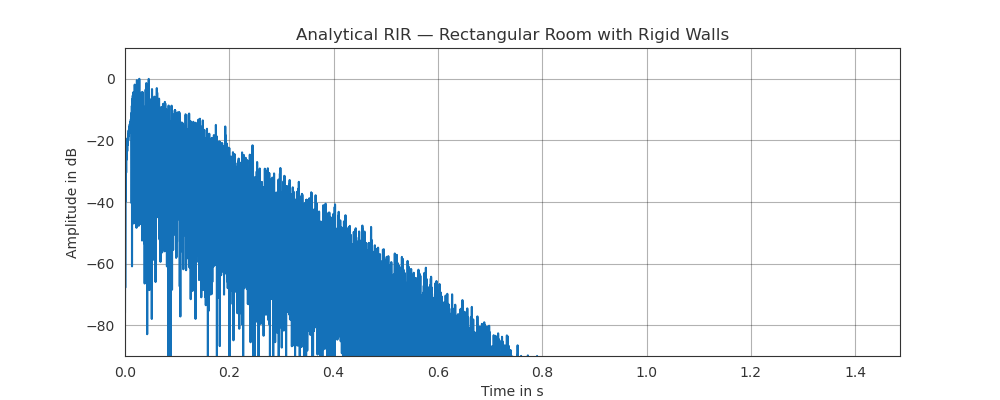

In [6]:
plt.figure(figsize=(10, 4))
pf.plot.time(rir_1, dB=True)
plt.title("Analytical RIR — Rectangular Room with Rigid Walls")
plt.show()

For the further investigations, we use a real room impulse response (RIR) provided by the [pyfar.signlas.files](https://pyfar.readthedocs.io/en/stable/modules/pyfar.signals.files.html#) module. This RIR was measured in the Berliner Philharmonie, a renowned concert hall in Berlin, Germany, specifically at emitter position 17 using a high-quality microphone and sound source to capture the hall's unique acoustic characteristics.

Loading it [pyfar.signals.files.room_impulse_response](https://pyfar.readthedocs.io/en/stable/modules/pyfar.signals.files.html#pyfar.signals.files.room_impulse_response) preserves the complete decay including the late reverberant tail, providing authentic data for analysis. Using this real Philharmonie RIR allows us to examine genuine room acoustics—direct sound, early reflections, diffusion from the hall's terraced architecture, and natural reverberation decay—making it ideal for demonstrating practical room acoustic parameter calculations like T20, C80, and STI.

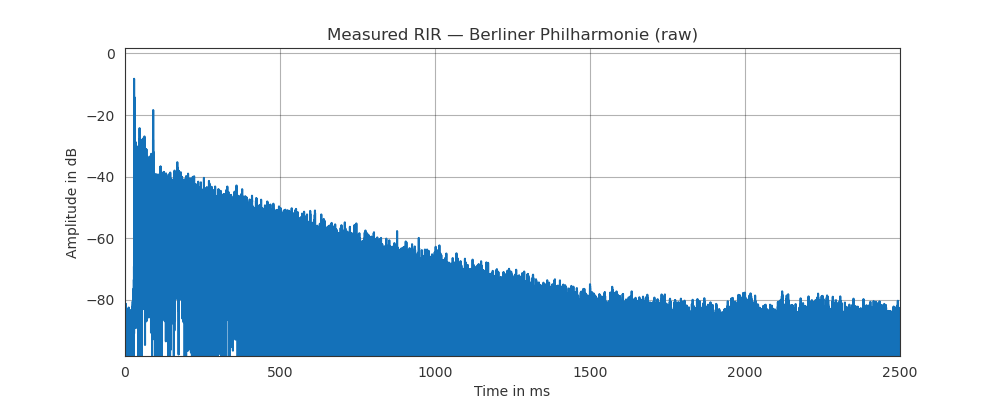

In [7]:
# Load measured RIR (Berliner Philharmonie, Emitter 17)
rir = pf.signals.files.room_impulse_response(sampling_rate=48000, crop_noise_tail=False)

plt.figure(figsize=(10, 4))
pf.plot.time(rir, unit='ms', dB=True)
plt.title("Measured RIR — Berliner Philharmonie (raw)")
plt.show()

## Pre-Processing

For frequency-dependent room acoustic analysis, the RIR is filtered into octave bands using [`pyfar.dsp.filter.fractional_octave_bands`](https://pyfar.readthedocs.io/en/stable/modules/pyfar.dsp.filter.html#pyfar.dsp.filter.fractional_octave_bands). This returns a multi-channel Signal where each channel corresponds to one octave band (e.g., 125 Hz, 250 Hz, 500 Hz, etc.), enabling separate analysis of how the Berliner Philharmonie's acoustics vary across the frequency spectrum.

The Philharmonie RIR is split into these standard ISO octave bands. This pre-processing step is essential because parameters like T20, C80, and STI are computed per frequency band to capture the hall's frequency-dependent behavior, from bass buildup in the low frequencies to clarity in the higher bands.

In [8]:
start_sample = pf.dsp.find_impulse_response_start(rir)
rir_shifted = pf.dsp.time_shift(rir, -start_sample, mode='linear')

# Filter into octave bands
rir_oct = pf.dsp.filter.fractional_octave_bands(
    rir_shifted, num_fractions=1, frequency_range=(125, 4000))
oct_freqs = pf.constants.fractional_octave_frequencies_nominal(
    num_fractions=1, frequency_range=(125, 4000))




## Interactive Plots

The band-passed RIRs can be inspected interactively. Pyfar provides convenient **keyboard shortcuts** for switching between channels, zooming, and panning.

**All following figures support interactive shortcuts.** If the plot does not respond, click the figure first to activate it.

Use `,` / `.` (DE keyboard) or `[` / `]` (EN keyboard) to cycle through octave bands. `Shift + a` toggles between showing all channels and a single channel.

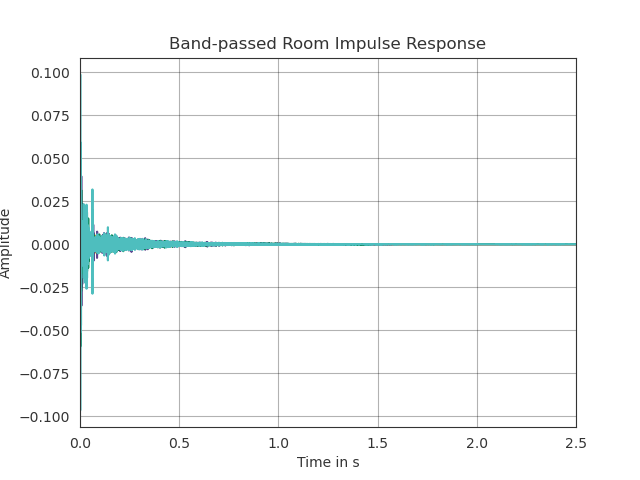

In [9]:
plt.figure()
pf.plot.time(rir_oct, unit='s', dB=False)
plt.title(f"Band-passed Room Impulse Response")
#plt.ylim(-90, 2)
plt.show()


## Room Acoustic Parameters
Room acoustic parameters quantify the perceptual quality of a room for music and speech. The 
[pyrato.parameters](https://pyrato.readthedocs.io/en/stable/modules/parameters.html) module provides implementations of ISO 3382 parameters calculated directly from the RIR or its octave-band filtered versions.

## Pre-Processing

For frequency-dependent room acoustic analysis the RIR is filtered into octave bands using [`pyfar.dsp.filter.fractional_octave_bands`](https://pyfar.readthedocs.io/en/stable/modules/pyfar.dsp.filter.html). This returns a multi-channel `Signal` where each channel corresponds to one octave band.

#### Full Impulse Response
When considering the full room impulse response for the EDC calculation, the plot below shows that the noise in the RIR introduces an error in the estimated EDC.

$$ E_{\mathrm{Full}}(t) = \int_t^{t_{IR}} h^2(\tau) d\tau  $$

$E(t)$ denotes the energy decay curve, $t$ the time, $t_{IR}$ the length of the impulse response and $h(\tau)$ the impulse response.

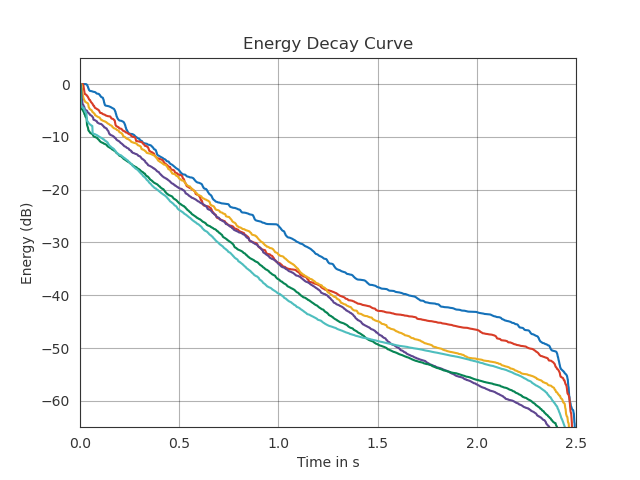

In [10]:
# Calculate the energy decay curve 
edc_schroeder = pr.edc.schroeder_integration(rir_oct, is_energy=False)
# Normierung: Jede Oktavband-Kurve durch ihren Startwert teilen
edc_schroeder.time /= edc_schroeder.time[..., 0][:, None]
plt.figure()
pf.plot.time(edc_schroeder, log_prefix=10, dB=True)
plt.ylim(-65, 5)
plt.ylabel("Energy (dB)")
plt.title("Energy Decay Curve")
plt.show()


#### Lundeby's Method 
Lundeby et al. [2] proposed a noise compensation method, where the RIR is truncated to the intersection time and additionally intruced a correction term $C_\mathrm{Comp}$.

$$ E_\mathrm{Lundeby}(t) = \int_t^{t_i} h^2(\tau) d\tau + C_\mathrm{Comp}  $$

$$C_\mathrm{Comp} = p_{i}^2 \cdot T_{60, late} \cdot \frac{1}{6 \cdot ln(10)} \cdot R_s $$

$p_{i}^2$ denotes the squared sound pressure at the intersection time, $T_{60, late}$ the late reverberation time after Lundeby and $R_s$ the sampling rate.


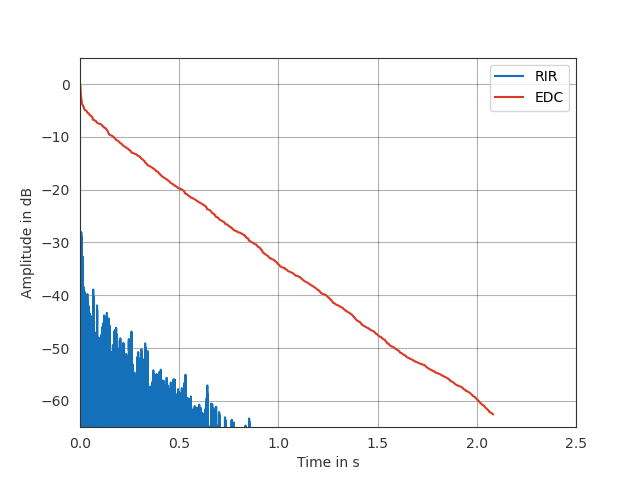

In [11]:
plt.figure()
edc_lundeby =  pr.edc.energy_decay_curve_lundeby(
        rir_oct[3],
        freq=1000,
        noise_level='auto',
        is_energy=False,
        time_shift=True,
        channel_independent=True,
        normalize=True,
        plot=True)



### Reverberation Time T20

The T20 is estimated by fitting a regression line to the part of the EDC between −5 dB and −25 dB, and extrapolating to a 60 dB decay. It is more robust than T30 in the presence of a noise floor.

In [12]:
T20 = pr.parameters.reverberation_time_linear_regression(edc_schroeder,T='T20',return_intercept=False)
print("frequency (Hz):", oct_freqs)
print("reverberation time T20 (s):",T20)

frequency (Hz): [ 125.  250.  500. 1000. 2000. 4000.]
reverberation time T20 (s): 

[[2.15896086]
 [1.80481202]
 [2.04604298]
 [2.02762113]
 [1.95439063]
 [1.70635061]]


### Clarity C80

The clarity C80 is the logarithmic energy ratio of the first 80 ms to the energy arriving after 80 ms. Positive values indicate high clarity (predominantly direct/early energy); negative values indicate more reverberant conditions. C80 is used to assess suitability for music performance.

In [13]:
# Calculate C80 per octave band
C80 = pr.parameters.clarity(edc_schroeder, early_time_limit=80)

print("frequency (Hz):", oct_freqs)
print("clarity  C80 (s):",C80)

frequency (Hz): [ 125.  250.  500. 1000. 2000. 4000.]
clarity  C80 (s): [[-3.23356558]
 [ 2.75047145]
 [ 4.70125989]
 [ 5.97972015]
 [ 9.66702791]
 [ 9.08796595]]


### Speech Transmission Index 

The STI quantifies speech intelligibility in a room, ranging from 0 (completely unintelligible) to 1 (perfect intelligibility). It is derived from the modulation transfer function of the room.

In [16]:
# male speech spectrum at 65 dB(A) (IEC 60268-16:2020, Annex B)
level = np.array([56, 60, 59, 51, 43, 32, 24])
# NC-35 classroom background noise (ANSI/ASA S12.2)
noise_level = np.array([52, 45, 40, 36, 34, 33, 32])
snr = level - noise_level
sssti = pr.parameters.speech_transmission_index_indirect(rir, rir_type="acoustical", level=level, snr=snr,
        ambient_noise_correction=True)

AttributeError: module 'pyrato.parameters' has no attribute 'speech_transmission_index_indirect'

# Other Packages
Now, feel free to have a look at [pyfar.org](https://pyfar.org) to get an idea of the pyfar sub-packages.

# License notice
This notebook © 2024 by [the pyfar developers](https://github.com/orgs/pyfar/people) is licensed under [CC BY 4.0](http://creativecommons.org/licenses/by/4.0/?ref=chooser-v1)

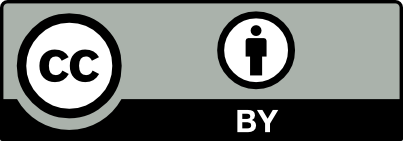


# Watermark

In [ ]:
%load_ext watermark
%watermark -v -m -iv